# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.model_selection import train_test_split

# Parameters

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.enabled = False
batch_size = 64
embedding_dim = 128
hidden_dim = 256
num_layers = 2
output_dim = 5
epochs = 25
lr = 0.001
max_grad_norm = 1.0

train_path = 'train.pkl'
test_path = 'test_no_target.pkl'

print(f"Using device: {device}")

Using device: cuda


# Data Loading & Vocabulary Building

In [3]:
with open(train_path, 'rb') as f:
    train_data_raw = pickle.load(f)

train_raw, val_raw = train_test_split(train_data_raw, test_size=0.2, random_state=42)

vocab = {'<PAD>': 0, '<UNK>': 1}
for seq, _ in train_data_raw:
    for chord in seq:
        if chord not in vocab:
            vocab[chord] = len(vocab)

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Train samples: {len(train_raw)} | Val samples: {len(val_raw)}")

class ComposerDataset(Dataset):
    def __init__(self, data, vocab, is_test=False):
        self.data = data
        self.vocab = vocab
        self.is_test = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if self.is_test:
            seq = self.data[idx]
        else:
            seq, label = self.data[idx]
        seq_indices = [self.vocab.get(chord, self.vocab['<UNK>']) for chord in seq]
        seq_tensor = torch.tensor(seq_indices, dtype=torch.long)
        if self.is_test:
            return seq_tensor
        return seq_tensor, label

def collate_fn_train(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in seqs], dtype=torch.long)
    padded_seqs = pad_sequence(seqs, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_seqs, lengths, labels

def collate_fn_test(batch):
    seqs = batch
    lengths = torch.tensor([len(seq) for seq in seqs], dtype=torch.long)
    padded_seqs = pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded_seqs, lengths

train_dataset = ComposerDataset(train_raw, vocab)
val_dataset = ComposerDataset(val_raw, vocab)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_train)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_train)


Vocabulary size: 184
Train samples: 2351 | Val samples: 588


# Recurrent Model (Bi-LSTM) Definition

In [4]:
class ComposerLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2):
        super(ComposerLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.conv = nn.Conv1d(in_channels=embedding_dim, 
                              out_channels=embedding_dim, 
                              kernel_size=3, 
                              padding=1)
        self.relu = nn.ReLU()
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, 
                            batch_first=True, bidirectional=True, dropout=0.5)
        
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        
        embedded = embedded.permute(0, 2, 1)
        conved = self.relu(self.conv(embedded))
        conved = conved.permute(0, 2, 1)
        
        packed_embedded = pack_padded_sequence(conved, text_lengths.cpu(), 
                                               batch_first=True, enforce_sorted=False)
        
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        x = self.dropout(hidden_concat)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        return self.fc2(x)

model = ComposerLSTM(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers).to(device)


# Training

In [5]:
model_path = 'composer_model.pt'
best_val_loss = float('inf')

try:
    history = torch.load('training_history.pt')
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Model loaded from {model_path}")
except FileNotFoundError:
    print(f"Model not found at {model_path}. Starting training...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting training process...")
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for seqs, lengths, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(seqs, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for seqs, lengths, labels in val_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                outputs = model(seqs, lengths)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_train_acc = 100 * train_correct / train_total
        epoch_val_acc = 100 * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        
        scheduler.step(epoch_val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f} VAL Loss: {epoch_val_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.2f}% VAL Acc: {epoch_val_acc:.2f}%")
        

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), model_path)
            print(f"New best model saved with VAL Loss: {best_val_loss:.4f}")

    torch.save(history, 'training_history.pt')

Model not found at composer_model.pt. Starting training...
Starting training process...
Epoch [1/25] | Train Loss: 1.2469 VAL Loss: 1.0386 | Train Acc: 54.32% VAL Acc: 61.39%
New best model saved with VAL Loss: 1.0386
Epoch [2/25] | Train Loss: 0.9081 VAL Loss: 0.7827 | Train Acc: 65.97% VAL Acc: 71.26%
New best model saved with VAL Loss: 0.7827
Epoch [3/25] | Train Loss: 0.7485 VAL Loss: 0.7135 | Train Acc: 73.71% VAL Acc: 73.98%
New best model saved with VAL Loss: 0.7135
Epoch [4/25] | Train Loss: 0.5991 VAL Loss: 0.4955 | Train Acc: 78.48% VAL Acc: 82.82%
New best model saved with VAL Loss: 0.4955
Epoch [5/25] | Train Loss: 0.4971 VAL Loss: 0.6088 | Train Acc: 82.01% VAL Acc: 80.78%
Epoch [6/25] | Train Loss: 0.4341 VAL Loss: 0.5275 | Train Acc: 84.30% VAL Acc: 83.16%
Epoch [7/25] | Train Loss: 0.3651 VAL Loss: 0.4144 | Train Acc: 86.35% VAL Acc: 85.03%
New best model saved with VAL Loss: 0.4144
Epoch [8/25] | Train Loss: 0.3171 VAL Loss: 0.4515 | Train Acc: 88.90% VAL Acc: 85.88%
E

# Result Visualization

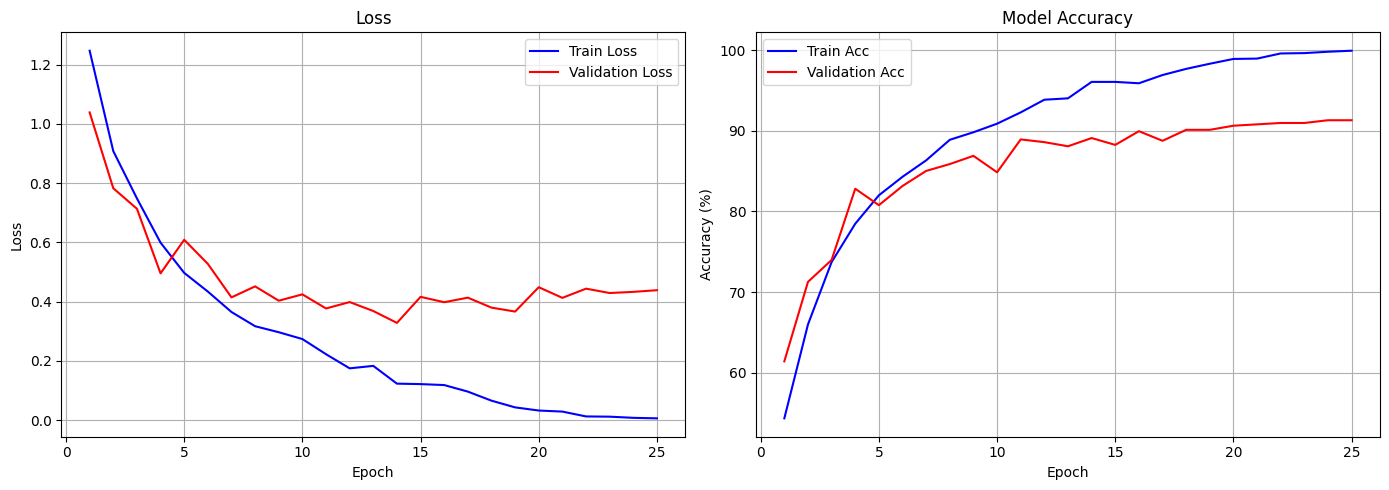

In [6]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
plt.plot(epochs_range, history['val_acc'], 'r-', label='Validation Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Inference on Test Set

In [7]:
with open(test_path, 'rb') as f:
    test_data_raw = pickle.load(f)

test_dataset = ComposerDataset(test_data_raw, vocab, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_test)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
all_predictions = []

print("Generating predictions for test set...")
with torch.no_grad():
    for seqs, lengths in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs, lengths)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())

df_preds = pd.DataFrame(all_predictions)
df_preds.to_csv('pred.csv', index=False, header=False)

print(f"Saved {len(all_predictions)} predictions to 'pred.csv'.")


Generating predictions for test set...
Saved 1103 predictions to 'pred.csv'.
